# Feature Extraction

A feature extractor turns an image into a grid of patch embeddings, one vector per image patch.
Queryable extractors (MaskCLIP, Talk2DINO) also embed text into the same space, so a single word
can be scored against every patch. This page runs both on one committed frame and shows their
features and the similarity map for one text query. DINOv2, which has no text side, and the OCR
lens, which has its own page, use the same interface.

In [1]:
import matplotlib.pyplot as plt
import transformers

from collab_splats.semantics import MaskCLIPExtractor, Talk2DinoExtractor
from collab_splats.utils.io import read_image
from collab_splats.utils.notebook import feature_viz_row

%run ../tutorial.py

# Talk2DINO's checkpoint carries PAMR kernels it does not load; silence that warning
transformers.logging.set_verbosity_error()

# One committed frame; no reconstruction needed
frame = read_image(QUERY_IMAGE)

## 1. Forward and score

`forward` takes a list of images and returns one `(D, H_p, W_p)` feature map per image, with
each patch vector normalized to unit length. `score_queries` compares the patches against the
positive queries and a negative ("object" by default) and returns an `(H_p, W_p)` map in [0, 1].
It takes the maximum over its positives, so to compare two prompts, call it once per prompt.
This page names the other things in the scene as negatives. Against "object" alone,
"tree" wins almost everywhere in a forest, and Talk2DINO scores every patch above 0.5.

In [2]:
# Text query scored against every patch
QUERY = "tree"
NEGATIVES = ["object", "background", "ground", "sky"]

extractors = {"MaskCLIP": MaskCLIPExtractor(), "Talk2DINO": Talk2DinoExtractor()}
maps = {}
scores = {}

# Patch features and one similarity map per extractor
for name, extractor in extractors.items():
    features = extractor.forward([frame])[0]
    score = extractor.score_queries(features, positive=[QUERY], negative=NEGATIVES)
    maps[name] = features
    scores[name] = score.cpu().numpy()

    print(name, tuple(features.shape))

MaskCLIP (768, 41, 73)


Talk2DINO (768, 18, 32)


The printed shapes show each extractor's feature width and patch grid, which are much coarser
than the image.

## 2. Features and query heatmap

`feature_viz_row` draws one row per extractor: the features projected to RGB by PCA, the
similarity heatmap for the query, and the image masked by that heatmap.

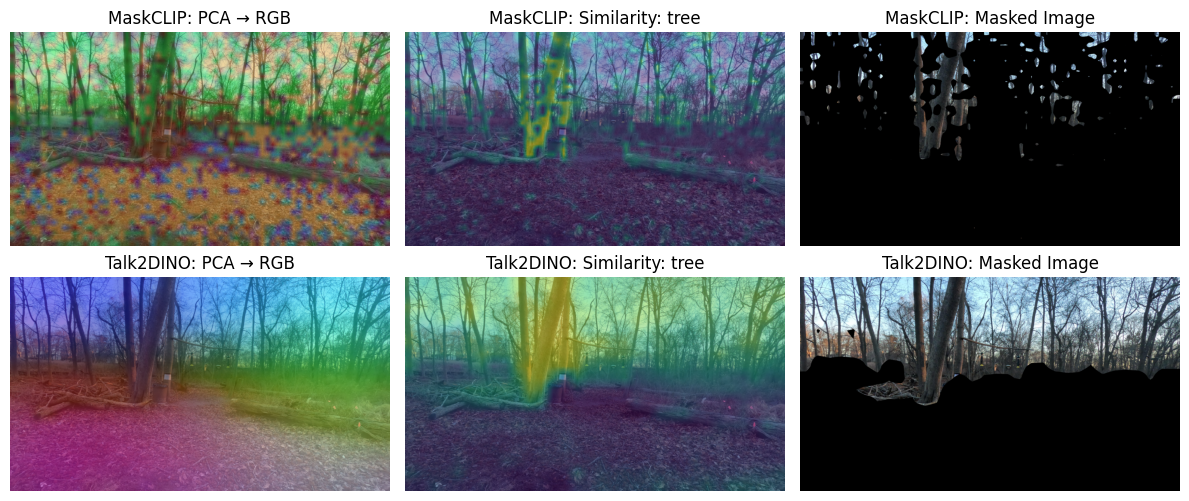

In [3]:
fig, axes = plt.subplots(len(extractors), 3, figsize=(12, 2.6 * len(extractors)))

# One row of PCA, heatmap and masked image per extractor
for row, name in enumerate(extractors):
    feature_viz_row(
        axes[row],
        frame,
        maps[name],
        scores[name],
        title_prefix=f"{name}: ",
        query_label=QUERY,
    )

plt.tight_layout()

Look at whether the heatmap lights up the trees and stays dark elsewhere, and compare how
sharply each extractor follows object boundaries in its PCA image.

## In a pipeline run

The `semantics` stage runs one extractor over every keyframe, stores the features in a
per-scene cache, and lifts them onto the mesh vertices (see the lifting and query page).
`semantics.extractor` picks the backend.

```yaml
semantics:
  enabled: true
  extractor: maskclip    # talk2dino | dinov2 | maskclip | ocr_lens
```